# **Rome Airbnb Clusterization**

**Project**: Airbnb Market Segmentation Analysis

**Goal**: Cluster Rome's Airbnb listings using the final feature set from EDA & Feature Selection, testing systematically whether NLP-derived signals reveal market structure invisible to tabular features alone, resolving the geography input, tuning k and gamma, and validating cluster stability before profiling the resulting segments.

## 1. Setup & Preprocessing

### 1.1 Imports & Environment

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [3]:
ROME_PALETTE = {
    'primary': '#8B3A3A', 'secondary': '#4C6B8A', 'accent': '#C9A227',
    'neutral': '#6B6B6B', 'light_bg': '#F5F1EC',
}
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})

### 1.2 Data Loading

In [4]:
listings = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_final.csv')

In [5]:
listings.drop(columns = ['Unnamed: 0'], inplace = True)
print(f"shape: {listings.shape}")
print(f"\ndtypes:\n{listings.dtypes.value_counts()}")

shape: (35818, 151)

dtypes:
float64    88
str        45
int64      18
Name: count, dtype: int64


### 1.3 Split Off External Variables

In [6]:
EXTERNAL_COLS = ['id', 'price', 'price_tier', 'latitude', 'longitude', 'neighbourhood_cleansed']

listing_ids = listings['id'].copy()
price = listings['price'].copy()
price_tier = listings['price_tier'].copy()
latitude = listings['latitude'].copy()
longitude = listings['longitude'].copy()
neighbourhood_cleansed = listings['neighbourhood_cleansed'].copy()

print("External variables:")
for name, series in [('listing_ids', listing_ids), ('price', price), ('price_tier', price_tier),
                       ('latitude', latitude), ('longitude', longitude)]:
    print(f"  {name}: {len(series)} values, {series.isna().sum()} NaN")

External variables:
  listing_ids: 35818 values, 0 NaN
  price: 35818 values, 3737 NaN
  price_tier: 35818 values, 0 NaN
  latitude: 35818 values, 0 NaN
  longitude: 35818 values, 0 NaN


### 1.4 The `has_reviews` Strata Split

Several review-derived columns go structurally missing/`Unknown` together for the same ~14% of listings. A listing with no reviews has no sentiment, no review score, no topic content, all at once. Left inside the clustering feature set, this synchronized absence inflates the distance between "has reviews" and "no reviews" listings across many columns simultaneously, risking a cluster defined by that one structural fact rather than by genuine market segmentation. Listings without reviews are set aside here for separate, descriptive profiling later, and clustering runs only on the population that actually has review data.

In [7]:
print(f"has_reviews value counts:\n{listings['has_reviews'].value_counts()}")

listings_no_review = listings[listings['has_reviews'] == 0].copy()
listings_reviewed = listings[listings['has_reviews'] == 1].copy()

print(f"\nlistings_no_review: {listings_no_review.shape[0]} rows ({listings_no_review.shape[0]/len(listings)*100:.1f}%)")
print(f"listings_reviewed: {listings_reviewed.shape[0]} rows ({listings_reviewed.shape[0]/len(listings)*100:.1f}%)")
print(f"\nrows accounted for: {listings_no_review.shape[0] + listings_reviewed.shape[0]} vs total {len(listings)}")


listing_ids = listing_ids.loc[listings_reviewed.index]
price = price.loc[listings_reviewed.index]
price_tier = price_tier.loc[listings_reviewed.index]
latitude = latitude.loc[listings_reviewed.index]
longitude = longitude.loc[listings_reviewed.index]
neighbourhood_cleansed = neighbourhood_cleansed.loc[listings_reviewed.index]

print(f"\nexternal variables re-aligned to listings_reviewed: {len(listing_ids)} rows each")

has_reviews value counts:
has_reviews
1    30718
0     5100
Name: count, dtype: int64

listings_no_review: 5100 rows (14.2%)
listings_reviewed: 30718 rows (85.8%)

rows accounted for: 35818 vs total 35818

external variables re-aligned to listings_reviewed: 30718 rows each


### 1.5 Splitting Features by Type

In [8]:
str_cols = listings_reviewed.select_dtypes(include='str').columns.tolist()
numeric_all = listings_reviewed.select_dtypes(include=[np.number]).columns.tolist()

EXCLUDE_FROM_NUMERIC = {'id', 'price', 'latitude', 'longitude'}
EXCLUDE_FROM_CAT = {'neighbourhood_cleansed'}

binary_cols = [c for c in numeric_all if c not in EXCLUDE_FROM_NUMERIC
               and set(listings_reviewed[c].dropna().unique()).issubset({0, 1})]
continuous_cols = [c for c in numeric_all if c not in binary_cols and c not in EXCLUDE_FROM_NUMERIC]
categorical_cols = [c for c in str_cols if c not in EXCLUDE_FROM_CAT and c != 'price_tier']

print(f"binary flags: {len(binary_cols)}")
print(f"continuous numeric: {len(continuous_cols)}")
print(f"string/nominal categorical: {len(categorical_cols)}")

all_clustering_cols = binary_cols + continuous_cols + categorical_cols
print(f"\ntotal clustering-input columns: {len(all_clustering_cols)}")
print(f"total listings_reviewed columns: {listings_reviewed.shape[1]}")
print(f"expected gap: {listings_reviewed.shape[1] - len(all_clustering_cols)}")

binary flags: 29
continuous numeric: 73
string/nominal categorical: 43

total clustering-input columns: 145
total listings_reviewed columns: 151
expected gap: 6


### 1.6 NLP vs. Tabular Classification

In [9]:
POST_STRATA_EXCLUDE = {'has_reviews', 'number_of_reviews'}
binary_cols = [c for c in binary_cols if c not in POST_STRATA_EXCLUDE]
continuous_cols = [c for c in continuous_cols if c not in POST_STRATA_EXCLUDE]

REDUNDANT_EXCLUDE = {'has_top5_amenity', 'portfolio_size_bin'}
binary_cols = [c for c in binary_cols if c not in REDUNDANT_EXCLUDE]
continuous_cols = [c for c in continuous_cols if c not in REDUNDANT_EXCLUDE]
categorical_cols = [c for c in categorical_cols if c not in REDUNDANT_EXCLUDE]

all_clustering_cols = binary_cols + continuous_cols + categorical_cols
all_clustering_cols_set = set(all_clustering_cols)

TABULAR_STRUCTURAL_COLS = {
    'geo_sector', 'distance_to_center_km_log',
    'property_type_grouped', 'accommodates_bin', 'accommodates_per_bedroom_binned',
    'bedrooms_binned', 'bathroom_count', 'beds_log', 'amenities_count',
    'has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym',
    'bath_private_info', 'bath_shared_info',
    'is_long_term_oriented', 'availability_ratio', 'availability_365_ratio', 'instant_bookable',
    'host_response_time', 'host_response_rate_binned', 'host_acceptance_rate_binned',
    'host_is_superhost', 'host_experience_years', 'calculated_host_listings_count_log',
    'median_review_length', 'reviews_per_month_binned', 'last_review_recency_binned',
    'review_engagement_score', 'review_quality_pc1_binned',
    'has_description', 'has_neighborhood_overview', 'has_host_about', 'has_response_data',
}

# check if every "tabular" name must actually exist in the data
phantom_tabular = TABULAR_STRUCTURAL_COLS - all_clustering_cols_set
assert not phantom_tabular, f"TABULAR_STRUCTURAL_COLS contains names not in the actual data: {phantom_tabular}"

NLP_COLS = all_clustering_cols_set - TABULAR_STRUCTURAL_COLS

print(f"total clustering columns: {len(all_clustering_cols_set)}")
print(f"tabular : {len(TABULAR_STRUCTURAL_COLS)}")
print(f"NLP : {len(NLP_COLS)}")

# check
assert len(TABULAR_STRUCTURAL_COLS) + len(NLP_COLS) == len(all_clustering_cols_set)

print(f"\nNLP_COLS ({len(NLP_COLS)} total):")
for col in sorted(NLP_COLS):
    print(f"  {col}")

total clustering columns: 141
tabular : 35
NLP : 106

NLP_COLS (106 total):
  desc_topic_amenities_wifi_ac_tv_weight
  desc_topic_bedroom_layout_weight
  desc_topic_building_character_weight
  desc_topic_metro_distance_meters_weight
  desc_topic_multi_bedroom_large_weight
  desc_topic_navona_pantheon_campo_fiori_weight_binned
  desc_topic_near_attractions_general_weight
  desc_topic_neighborhood_liveliness_weight
  desc_topic_piazza_spagna_trevi_weight
  desc_topic_room_type_private_shared_weight
  desc_topic_san_giovanni_colosseum_weight_binned
  desc_topic_termini_train_airport_weight
  desc_topic_vatican_museums_weight
  desc_topic_walk_minutes_weight
  description_atmosphere_lively_density_log
  description_atmosphere_quiet_density_log
  description_authenticity_density_log
  description_budget_density_binned
  description_direct_address_density_log
  description_exclaim_count_binned
  description_family_density_binned
  description_landmark_count_log
  description_luxury_density_l

### 1.7 Ordinal Recoding for the Ordered Categories

Some categorical columns encode a real, such as `1 Bedroom` is meaningfully "less" than `3+ Bedrooms`, but as plain strings, Gower/Hamming distance treats every mismatch identically, whether it's `Studio` vs. `1 Bedroom` or `Studio` vs. `3+ Bedrooms`. Recoding these as small integers and placing them in the continuous block preserves that ordering information instead of discarding it. Only columns with a genuinely unambiguous, total order are recoded this way, anything with ties, an `Unknown`/non-ordered category, or no natural ranking stays in the categorical block as-is.

In [10]:
final_categorical_cols = [c for c in categorical_cols]  

print(f"{len(final_categorical_cols)} categorical columns to review:\n")
for col in sorted(final_categorical_cols):
    categories = sorted(listings_reviewed[col].unique())
    print(f"{col} ({len(categories)}): {categories}")

42 categorical columns to review:

accommodates_bin (4): ['1-2', '3-4', '5-6', '7+']
accommodates_per_bedroom_binned (5): ['High', 'Low', 'Studio', 'Typical', 'Unknown']
bedrooms_binned (5): ['1 Bedroom', '2 Bedrooms', '3+ Bedrooms', 'Studio', 'Unknown']
desc_topic_navona_pantheon_campo_fiori_weight_binned (4): ['Unknown', 'high', 'low', 'none']
desc_topic_san_giovanni_colosseum_weight_binned (4): ['Unknown', 'high', 'low', 'none']
description_budget_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_exclaim_count_binned (4): ['0', '1', '2+', 'Unknown']
description_family_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_mtld_binned (4): ['High', 'Low', 'Medium', 'Unknown']
description_readability_binned (4): ['High', 'Low', 'Medium', 'Unknown']
description_romantic_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_we_ref_density_binned (4): ['Unknown', 'high', 'low', 'none']
geo_sector (8): ['E', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'W']


In [11]:
UNKNOWN_SYNONYMS = {'unavailable', 'unknown', 'nan', 'none_available'}
CASE_PRESERVE_COLS = {'geo_sector'}  

def normalize_category_labels(series, preserve_case=False):
    """Lowercases every label for consistency (unless preserve_case), then folds
    any unknown-synonym (case-insensitive) into a single canonical 'unknown' label."""
    cleaned = series.astype(str).str.strip()
    is_unknown_variant = cleaned.str.lower().isin(UNKNOWN_SYNONYMS)
    if not preserve_case:
        cleaned = cleaned.str.lower()
    cleaned = cleaned.where(~is_unknown_variant, 'unknown')
    return cleaned

normalization_report = []
for col in categorical_cols:
    before = set(listings_reviewed[col].unique())
    listings_reviewed[col] = normalize_category_labels(listings_reviewed[col], preserve_case=col in CASE_PRESERVE_COLS)
    after = set(listings_reviewed[col].unique())
    if before != after:
        normalization_report.append({'column': col, 'before': sorted(before), 'after': sorted(after)})

print(f"{len(normalization_report)} columns had labels normalized:\n")
for entry in normalization_report:
    print(f"{entry['column']}:")
    print(f"  before: {entry['before']}")
    print(f"  after:  {entry['after']}")
    print()

40 columns had labels normalized:

host_response_time:
  before: ['Unknown', 'a few days or more', 'within a day', 'within a few hours', 'within an hour']
  after:  ['a few days or more', 'unknown', 'within a day', 'within a few hours', 'within an hour']

bedrooms_binned:
  before: ['1 Bedroom', '2 Bedrooms', '3+ Bedrooms', 'Studio', 'Unknown']
  after:  ['1 bedroom', '2 bedrooms', '3+ bedrooms', 'studio', 'unknown']

host_acceptance_rate_binned:
  before: ['Full Acceptance', 'Partial Acceptance', 'Unknown']
  after:  ['full acceptance', 'partial acceptance', 'unknown']

host_response_rate_binned:
  before: ['Full Response', 'Partial Response', 'Unknown']
  after:  ['full response', 'partial response', 'unknown']

reviews_per_month_binned:
  before: ['High Demand', 'Low Demand', 'Moderate Demand']
  after:  ['high demand', 'low demand', 'moderate demand']

last_review_recency_binned:
  before: ['Active', 'Dormant', 'Moderate']
  after:  ['active', 'dormant', 'moderate']

property_type_

Four columns carry a genuine order and no `Unknown` category at all: guest capacity tiers, review recency, review demand level, and review quality. As plain strings, Hamming distance would treat any two mismatched categories as equally different, discarding the fact that `1-2` sits closer to `3-4` than to `7+`. Recoding these as small integers and moving them into the continuous block preserves that ordering directly in the distance calculation instead of losing it.

In [12]:
# direct ordinal recode
GROUP_A_ORDINAL_MAPS = {
    'accommodates_bin': {'1-2': 0, '3-4': 1, '5-6': 2, '7+': 3},
    'last_review_recency_binned': {'active': 0, 'moderate': 1, 'dormant': 2},
    'reviews_per_month_binned': {'low demand': 0, 'moderate demand': 1, 'high demand': 2},
    'review_quality_pc1_binned': {'below average': 0, 'above average': 1},
}

for col, mapping in GROUP_A_ORDINAL_MAPS.items():
    actual = set(listings_reviewed[col].unique())
    expected = set(mapping.keys())
    assert actual == expected, f"{col}: actual={sorted(actual)} != expected={sorted(expected)}"

    listings_reviewed[f'{col}_ordinal'] = listings_reviewed[col].map(mapping)
    assert listings_reviewed[f'{col}_ordinal'].isna().sum() == 0, f"{col}_ordinal has unexpected NaN after mapping"

    # move from categorical to continuous
    categorical_cols.remove(col)
    continuous_cols.append(f'{col}_ordinal')

    print(f"{col} -> {col}_ordinal: {mapping}")

accommodates_bin -> accommodates_bin_ordinal: {'1-2': 0, '3-4': 1, '5-6': 2, '7+': 3}
last_review_recency_binned -> last_review_recency_binned_ordinal: {'active': 0, 'moderate': 1, 'dormant': 2}
reviews_per_month_binned -> reviews_per_month_binned_ordinal: {'low demand': 0, 'moderate demand': 1, 'high demand': 2}
review_quality_pc1_binned -> review_quality_pc1_binned_ordinal: {'below average': 0, 'above average': 1}


These eight tone/topic columns already carry a `none` level, meaning "the field existed, and this theme was measured at exactly zero." Their `Unknown` values, however, all trace back to the same underlying fact already recorded elsewhere in the feature set: the source field itself was never filled in. Since that fact is already captured independently, keeping `Unknown` as a separate category here would just count the same missing-field signal twice. `Unknown` is merged into `none`, and the resulting three clean levels (`none`/`low`/`high`, or `0`/`1`/`2+` for the exclaim-count column) are recoded as ordinal integers and moved into the continuous block.

In [13]:
# merge unknown -> none, then ordinal recode

GROUP_B_ORDINAL_MAPS = {
    'description_budget_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_family_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_romantic_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_we_ref_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'host_about_family_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'neighborhood_overview_luxury_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'neighborhood_overview_we_ref_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_exclaim_count_binned': {'0': 0, '1': 1, '2+': 2},
}

for col, mapping in GROUP_B_ORDINAL_MAPS.items():
    # merge unknown -> none 
    zero_label = '0' if col == 'description_exclaim_count_binned' else 'none'
    before_unknown = (listings_reviewed[col] == 'unknown').sum()
    listings_reviewed[col] = listings_reviewed[col].replace('unknown', zero_label)
    after_unknown = (listings_reviewed[col] == 'unknown').sum()

    # verify categories match expectation exactly before mapping
    actual = set(listings_reviewed[col].unique())
    expected = set(mapping.keys())
    assert actual == expected, f"{col}: actual={sorted(actual)} != expected={sorted(expected)}"

    listings_reviewed[f'{col}_ordinal'] = listings_reviewed[col].map(mapping)
    assert listings_reviewed[f'{col}_ordinal'].isna().sum() == 0, f"{col}_ordinal has unexpected NaN after mapping"

    # move from categorical to continuous
    categorical_cols.remove(col)
    continuous_cols.append(f'{col}_ordinal')

    print(f"{col}: merged {before_unknown} unknown -> {zero_label} ({after_unknown} remain), then recoded {mapping}")

description_budget_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_family_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_romantic_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_we_ref_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
host_about_family_density_binned: merged 16802 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
neighborhood_overview_luxury_density_binned: merged 15227 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
neighborhood_overview_we_ref_density_binned: merged 15227 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_exclaim_count_binned: merged 741 unknown -> 0 (0 remain), then recoded {'0': 0, '1': 1, '2+': 2}


In [14]:
GROUP_A_ORIGINAL_COLS = list(GROUP_A_ORDINAL_MAPS.keys())
GROUP_B_ORIGINAL_COLS = list(GROUP_B_ORDINAL_MAPS.keys())

cols_to_drop = GROUP_A_ORIGINAL_COLS + GROUP_B_ORIGINAL_COLS
still_present = [c for c in cols_to_drop if c in listings_reviewed.columns]
print(f"dropping {len(still_present)} superseded columns: {still_present}")

listings_reviewed = listings_reviewed.drop(columns=still_present)

# sanity check
leftover_in_tracking = set(cols_to_drop) & (set(categorical_cols) | set(continuous_cols) | set(binary_cols))
print(f"leftover old names in tracking lists: {leftover_in_tracking if leftover_in_tracking else 'none'}")

print(f"\nlistings_reviewed shape: {listings_reviewed.shape}")

dropping 12 superseded columns: ['accommodates_bin', 'last_review_recency_binned', 'reviews_per_month_binned', 'review_quality_pc1_binned', 'description_budget_density_binned', 'description_family_density_binned', 'description_romantic_density_binned', 'description_we_ref_density_binned', 'host_about_family_density_binned', 'neighborhood_overview_luxury_density_binned', 'neighborhood_overview_we_ref_density_binned', 'description_exclaim_count_binned']
leftover old names in tracking lists: none

listings_reviewed shape: (30718, 151)


In [15]:
# swap the 4 Group A tabular columns' old names for their new _ordinal names in
# TABULAR_STRUCTURAL_COLS — the 8 Group B columns need no such swap, since they
# were already NLP and NLP_COLS is derived as the complement, not listed by hand
TABULAR_STRUCTURAL_COLS -= set(GROUP_A_ORIGINAL_COLS)
TABULAR_STRUCTURAL_COLS |= {f'{c}_ordinal' for c in GROUP_A_ORIGINAL_COLS}

# rebuild the master list and verify no leaks, no phantoms, no double-counting
all_clustering_cols = binary_cols + continuous_cols + categorical_cols
all_clustering_cols_set = set(all_clustering_cols)

phantom_tabular = TABULAR_STRUCTURAL_COLS - all_clustering_cols_set
NLP_COLS = all_clustering_cols_set - TABULAR_STRUCTURAL_COLS

assert not phantom_tabular, f"phantom tabular entries: {phantom_tabular}"
assert len(TABULAR_STRUCTURAL_COLS) + len(NLP_COLS) == len(all_clustering_cols_set)

print(f"listings_reviewed shape: {listings_reviewed.shape}")
print(f"categorical_cols: {len(categorical_cols)} (Group C only)")
print(f"continuous_cols: {len(continuous_cols)} (+12 from Groups A/B)")
print(f"total clustering columns: {len(all_clustering_cols_set)}")
print(f"tabular: {len(TABULAR_STRUCTURAL_COLS)}, NLP: {len(NLP_COLS)}")

listings_reviewed shape: (30718, 151)
categorical_cols: 30 (Group C only)
continuous_cols: 84 (+12 from Groups A/B)
total clustering columns: 141
tabular: 35, NLP: 106


In [16]:
print(f"binary_cols count: {len(binary_cols)}")
print(binary_cols)

# sanity check: confirm none of the 29 binary flags accidentally ended up in
# continuous_cols or categorical_cols already — they should exist only in
# their own tracked list until assembly
overlap_with_continuous = set(binary_cols) & set(continuous_cols)
overlap_with_categorical = set(binary_cols) & set(categorical_cols)
print(f"\noverlap with continuous_cols (MUST be empty): {overlap_with_continuous if overlap_with_continuous else 'none'}")
print(f"overlap with categorical_cols (MUST be empty): {overlap_with_categorical if overlap_with_categorical else 'none'}")

binary_cols count: 27
['host_is_superhost', 'instant_bookable', 'bath_private_info', 'bath_shared_info', 'has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym', 'has_response_data', 'is_long_term_oriented', 'has_description', 'has_neighborhood_overview', 'has_host_about', 'has_neighborhood_overview_exclaim', 'has_description_self_ref', 'has_neighborhood_overview_self_ref', 'has_host_about_luxury', 'has_host_about_budget', 'has_host_about_atmosphere_quiet', 'has_host_about_atmosphere_lively', 'has_neighborhood_overview_family', 'has_neighborhood_overview_budget', 'has_neighborhood_overview_romantic', 'has_host_about_professionalism', 'is_all_positive_sentiment', 'has_no_neutral_sentiment']

overlap with continuous_cols (MUST be empty): none
overlap with categorical_cols (MUST be empty): none


### 1.8 Build the Final Clustering Matrix

In [17]:
from sklearn.preprocessing import StandardScaler

# binary flags join the categorical block as strings
X_categorical = listings_reviewed[categorical_cols + binary_cols].copy()
for col in binary_cols:
    X_categorical[col] = X_categorical[col].astype(int).astype(str)

X_continuous = listings_reviewed[continuous_cols].copy()
scaler = StandardScaler()
X_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(X_continuous),
    columns=continuous_cols,
    index=listings_reviewed.index
)

print(f"X_categorical: {X_categorical.shape} ({len(categorical_cols)} nominal + {len(binary_cols)} binary-as-string)")
print(f"X_continuous_scaled: {X_continuous_scaled.shape}")

print(f"\nX_categorical any NaN: {X_categorical.isna().any().any()}")
print(f"X_continuous_scaled any NaN: {X_continuous_scaled.isna().any().any()}")
print(f"X_continuous_scaled mean: {X_continuous_scaled.mean().abs().max():.6f}")
print(f"X_continuous_scaled std: {X_continuous_scaled.std().min():.4f} to {X_continuous_scaled.std().max():.4f}")

X_combined = pd.concat([X_continuous_scaled, X_categorical], axis=1)
categorical_indices = list(range(len(continuous_cols), X_combined.shape[1]))

print(f"\nX_combined shape: {X_combined.shape}")
print(f"categorical column indices: {categorical_indices[0]} to {categorical_indices[-1]} "
      f"({len(categorical_indices)} categorical columns)")

# sanity check: external columns genuinely absent from the clustering matrix
leaked = {'id', 'price', 'price_tier', 'latitude', 'longitude', 'neighbourhood_cleansed'} & set(X_combined.columns)
print(f"\nleaked external columns in X_combined: {leaked if leaked else 'none — clean'}")

# sanity check: row alignment preserved throughout
print(f"listing_ids length: {len(listing_ids)}, X_combined length: {len(X_combined)}")
print(f"indices match: {(listing_ids.index == X_combined.index).all()}")

X_categorical: (30718, 57) (30 nominal + 27 binary-as-string)
X_continuous_scaled: (30718, 84)

X_categorical any NaN: False
X_continuous_scaled any NaN: False
X_continuous_scaled mean: 0.000000
X_continuous_scaled std: 1.0000 to 1.0000

X_combined shape: (30718, 141)
categorical column indices: 84 to 140 (57 categorical columns)

leaked external columns in X_combined: none — clean
listing_ids length: 30718, X_combined length: 30718
indices match: True


This section builds the feature set clustering will run on. Listings with no reviews (14.2%) are split off entirely into their own population. Several review-derived columns go missing together for these listings, and left inside the clustering input, that synchronized absence would risk dominating the distance calculation on its own rather than reflecting genuine market structure. Twelve categorical columns with a genuine order (four clean, eight where `Unknown` safely folds into an existing `none` level) are recoded as integers instead of staying plain strings, so K-Prototypes' distance reflects that order rather than treating every mismatch as equally different. The result is `X_combined`: 141 features (84 continuous, 57 categorical including 27 binary flags) across 30,718 reviewed listings.

## 2. No-Review Strata 

14.2% of listings have never received a review. These aren't simply "missing data" to work around silently. Before setting them aside, this section gives them their own honest description: who are these listings, and how do they differ from the market clustering will actually run on.

### 2.1 Scale & Basic Comparison

In [18]:
comparison_summary = pd.DataFrame({
    'no_review': [
        len(listings_no_review),
        listings_no_review['price'].median(),
        listings_no_review['distance_to_center_km_log'].apply(np.expm1).median(),
        listings_no_review['calculated_host_listings_count_log'].apply(np.expm1).median(),
    ],
    'reviewed': [
        len(listings_reviewed),
        listings_reviewed['price'].median(),
        listings_reviewed['distance_to_center_km_log'].apply(np.expm1).median(),
        listings_reviewed['calculated_host_listings_count_log'].apply(np.expm1).median(),
    ],
}, index=['n_listings', 'median_price_eur', 'median_distance_km', 'median_portfolio_size'])

display(comparison_summary.round(1))

,no_review,reviewed
n_listings,5100.0,30718.0
median_price_eur,141.0,129.0
median_distance_km,3.1,2.6
median_portfolio_size,3.0,2.0


No-review listings are consistently different, not just newer copies of the reviewed population: median price runs €12 higher, they sit further from the center, and their hosts manage larger portfolios. This is a first hint against the "brand new, still finding its feet" story often assumed for review-less listings.

### 2.2 Price Distribution Comparison

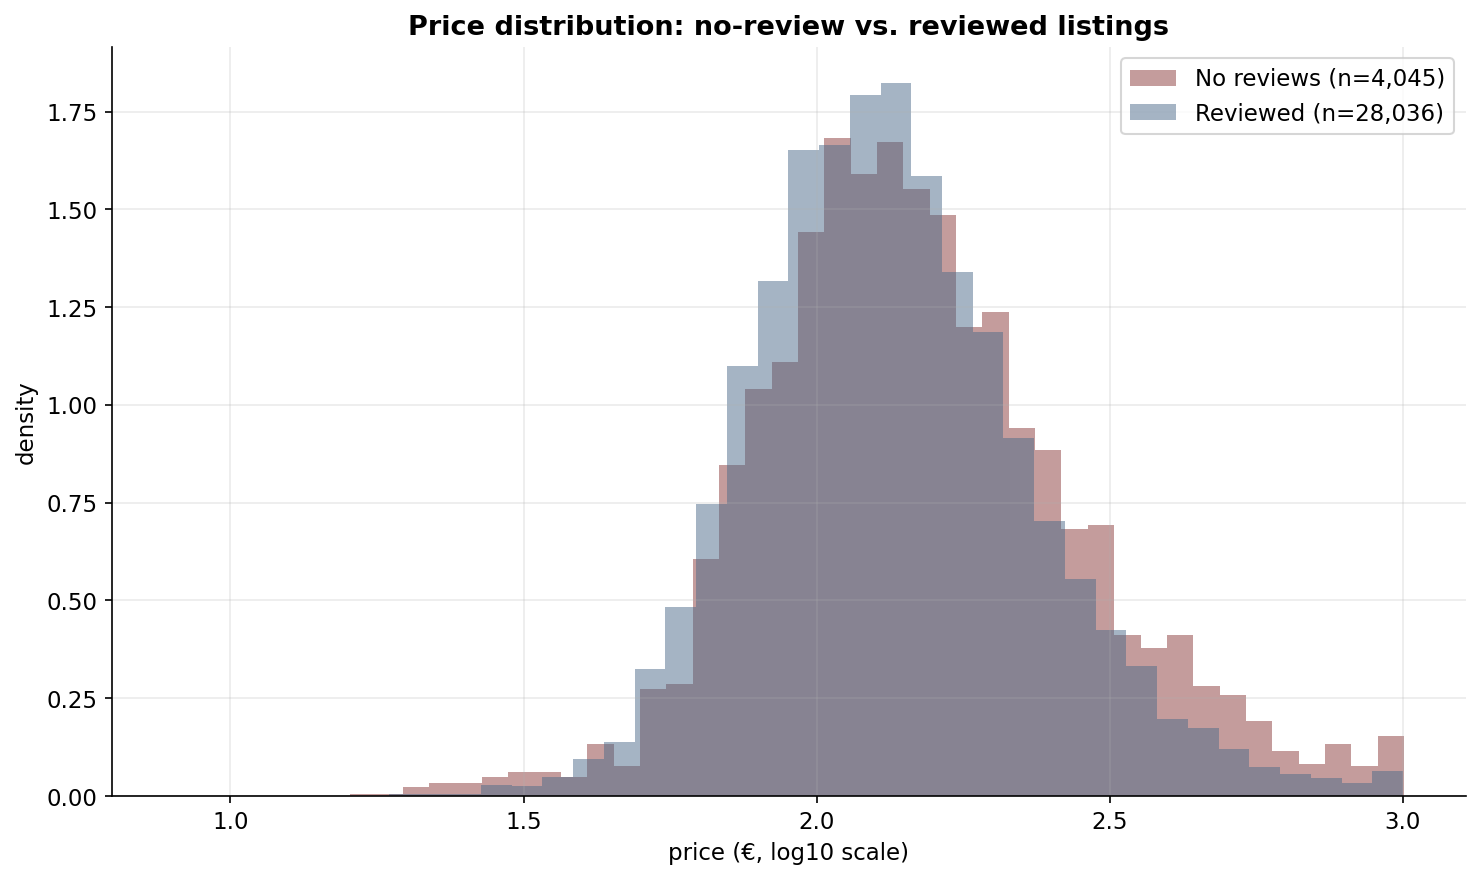

Mann-Whitney U test: p=0.0000000000000000 (significant difference)


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for data, label, color in [(listings_no_review['price'].dropna(), 'No reviews', ROME_PALETTE['primary']),
                              (listings_reviewed['price'].dropna(), 'Reviewed', ROME_PALETTE['secondary'])]:
    log_data = np.log10(data[data > 0])
    ax.hist(log_data, bins=40, alpha=0.5, density=True, label=f'{label} (n={len(data):,})', color=color)

ax.set_xlabel('price (€, log10 scale)')
ax.set_ylabel('density')
ax.set_title('Price distribution: no-review vs. reviewed listings')
ax.legend()
plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(listings_no_review['price'].dropna(), listings_reviewed['price'].dropna())
print(f"Mann-Whitney U test: p={pval:.16f} ({'significant' if pval < 0.05 else 'not significant'} difference)")

### 2.3 Property Type & Structure Comparison

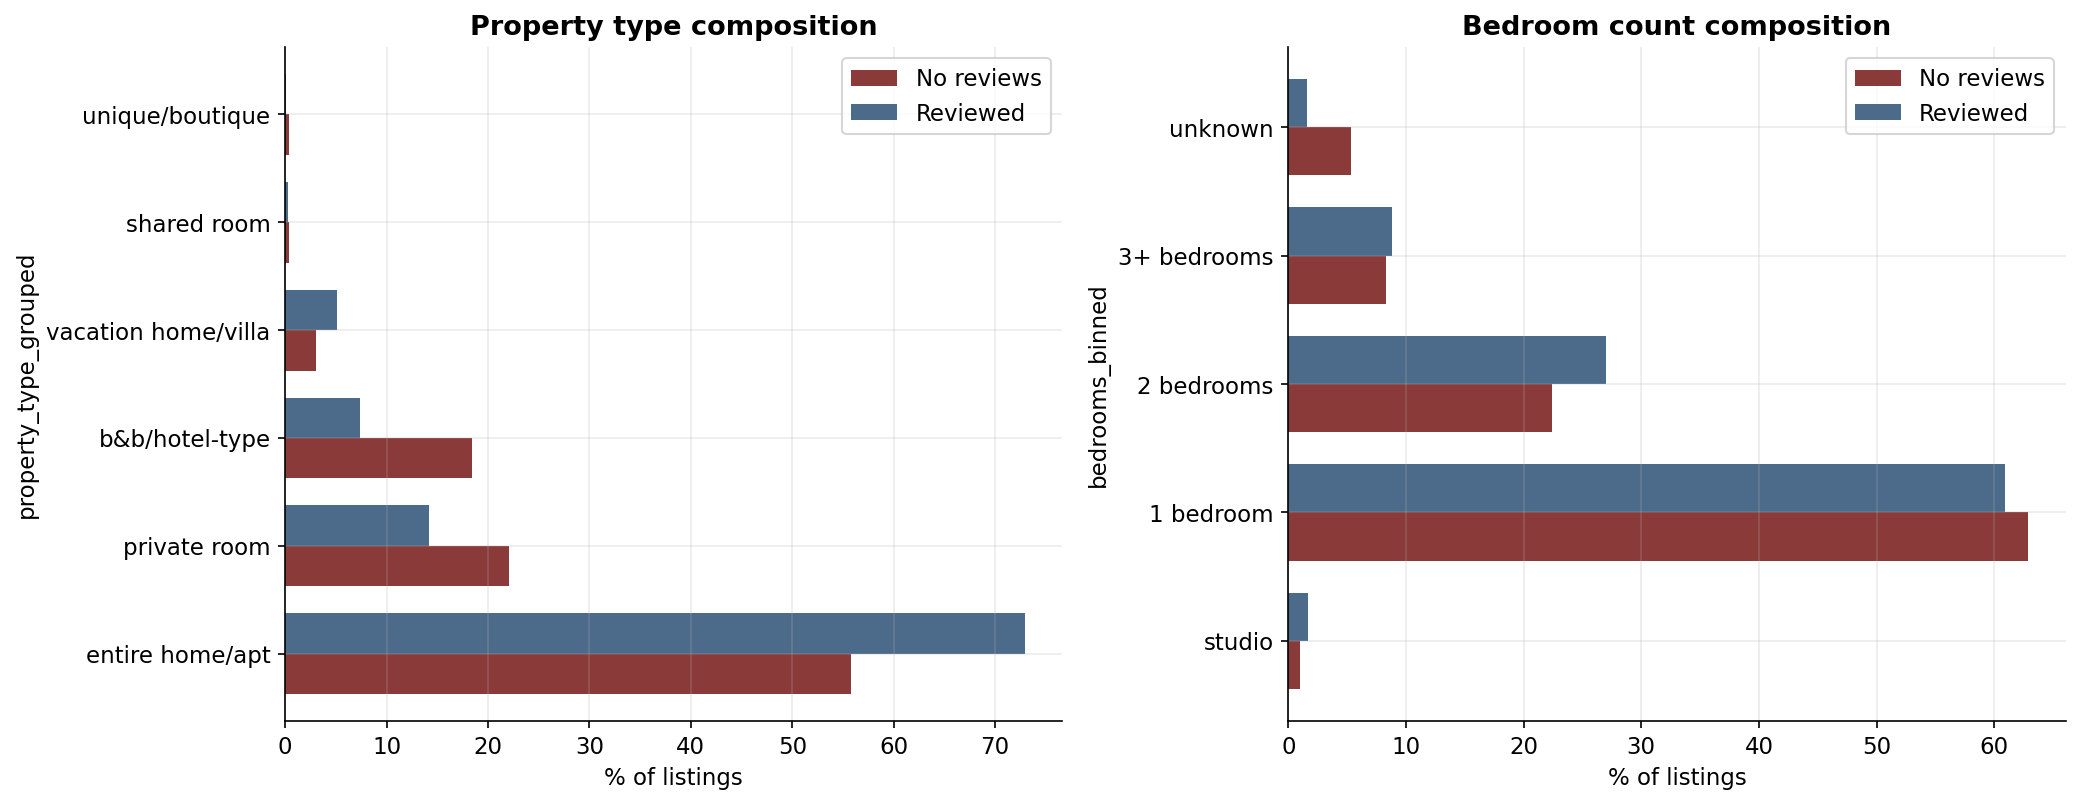

,No reviews,Reviewed
property_type_grouped,,
entire home/apt,55.7,73.0
private room,22.1,14.2
b&b/hotel-type,18.4,7.4
vacation home/villa,3.0,5.1
shared room,0.4,0.3
unique/boutique,0.3,0.1


,No reviews,Reviewed
bedrooms_binned,,
studio,1.0,1.7
1 bedroom,62.9,60.9
2 bedrooms,22.4,27.0
3+ bedrooms,8.3,8.8
unknown,5.4,1.6


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

no_review_prop = listings_no_review['property_type_grouped'].str.lower().value_counts(normalize=True).mul(100)
reviewed_prop = listings_reviewed['property_type_grouped'].value_counts(normalize=True).mul(100)

prop_compare = pd.DataFrame({'No reviews': no_review_prop, 'Reviewed': reviewed_prop}).fillna(0)
prop_compare.plot(kind='barh', ax=axes[0], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
axes[0].set_xlabel('% of listings')
axes[0].set_title('Property type composition')

no_review_bed = listings_no_review['bedrooms_binned'].str.lower().value_counts(normalize=True).mul(100)
reviewed_bed = listings_reviewed['bedrooms_binned'].value_counts(normalize=True).mul(100)
bed_order = [b for b in ['studio', '1 bedroom', '2 bedrooms', '3+ bedrooms', 'unknown'] if b in no_review_bed.index or b in reviewed_bed.index]

bed_compare = pd.DataFrame({'No reviews': no_review_bed, 'Reviewed': reviewed_bed}).reindex(bed_order).fillna(0)
bed_compare.plot(kind='barh', ax=axes[1], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
axes[1].set_xlabel('% of listings')
axes[1].set_title('Bedroom count composition')

plt.tight_layout()
plt.show()

display(prop_compare.round(1))
display(bed_compare.round(1))

Property type shows a structural difference: no-review listings skew toward B&B/hotel-type and private rooms, while the reviewed population is more concentrated in entire home/apt. This makes sense alongside the earlier portfolio-size finding: B&B/hotel-type listings often belong to small commercial operations, which may list many units at once, structurally diluting how quickly any single one accumulates its first reviews. Bedroom count, by contrast, shows almost no difference between the two populations.

### 2.4 Geographic Distribution Comparison

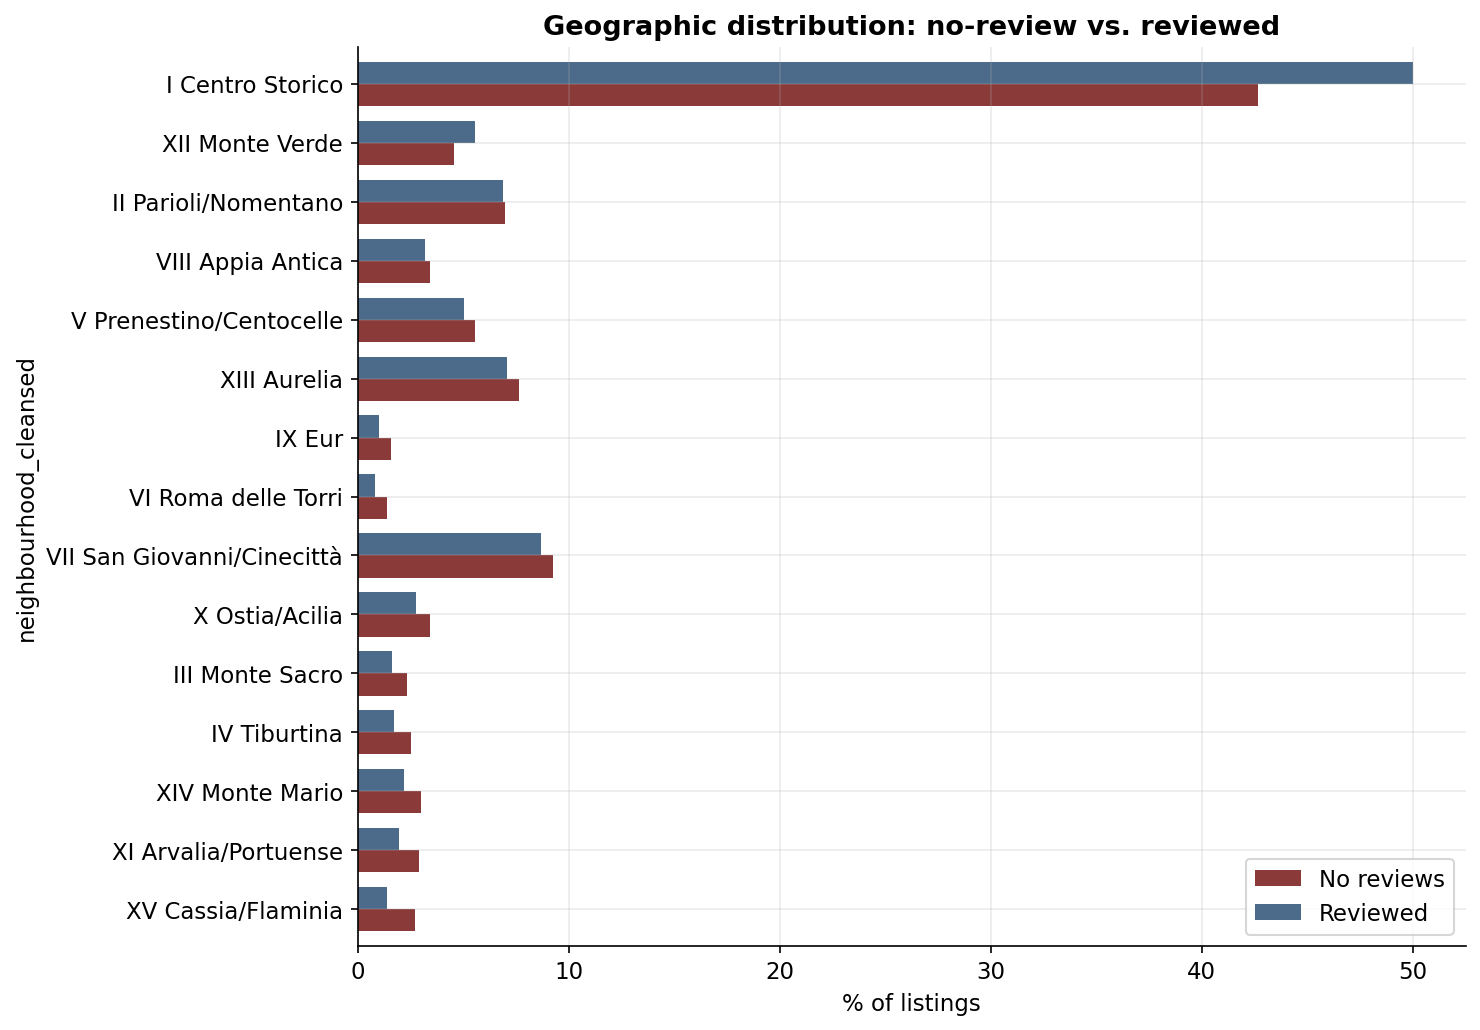

,No reviews,Reviewed,difference
neighbourhood_cleansed,,,
XV Cassia/Flaminia,2.7,1.4,1.3
XI Arvalia/Portuense,2.9,2.0,0.9
XIV Monte Mario,3.0,2.2,0.8
IV Tiburtina,2.5,1.7,0.8
III Monte Sacro,2.3,1.7,0.7
X Ostia/Acilia,3.4,2.8,0.7
VII San Giovanni/Cinecittà,9.3,8.7,0.6
VI Roma delle Torri,1.4,0.8,0.6
IX Eur,1.6,1.0,0.6


In [21]:
no_review_geo = listings_no_review['neighbourhood_cleansed'].value_counts(normalize=True).mul(100)
reviewed_geo = listings_reviewed['neighbourhood_cleansed'].value_counts(normalize=True).mul(100)

geo_compare = pd.DataFrame({'No reviews': no_review_geo, 'Reviewed': reviewed_geo}).fillna(0)
geo_compare['difference'] = geo_compare['No reviews'] - geo_compare['Reviewed']
geo_compare = geo_compare.sort_values('difference', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
geo_compare[['No reviews', 'Reviewed']].plot(kind='barh', ax=ax, color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
ax.set_xlabel('% of listings')
ax.set_title('Geographic distribution: no-review vs. reviewed')
plt.tight_layout()
plt.show()

display(geo_compare.round(1))

Geographic distribution is largely flat. Most municipi differ by under 1 percentage point between the two populations, with one meaningful exception: **I Centro Storico is under-represented among no-review listings by 7.3 points**,. This is the single clearest geographic signal in this comparison: the market's densest and most saturated district, is where a new listing has the hardest time staying review-less, plausibly because it's also the most search-visible, most frequently booked area, so listings there accumulate their first review fastest. No-review listings correspondingly skew slightly toward every other municipio, spread thinly rather than concentrated in any one peripheral area.

### 2.5 Host & Stay-Orientation Check

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67614/3956479842.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(portfolio_data, labels=['No reviews', 'Reviewed'], showfliers=False)


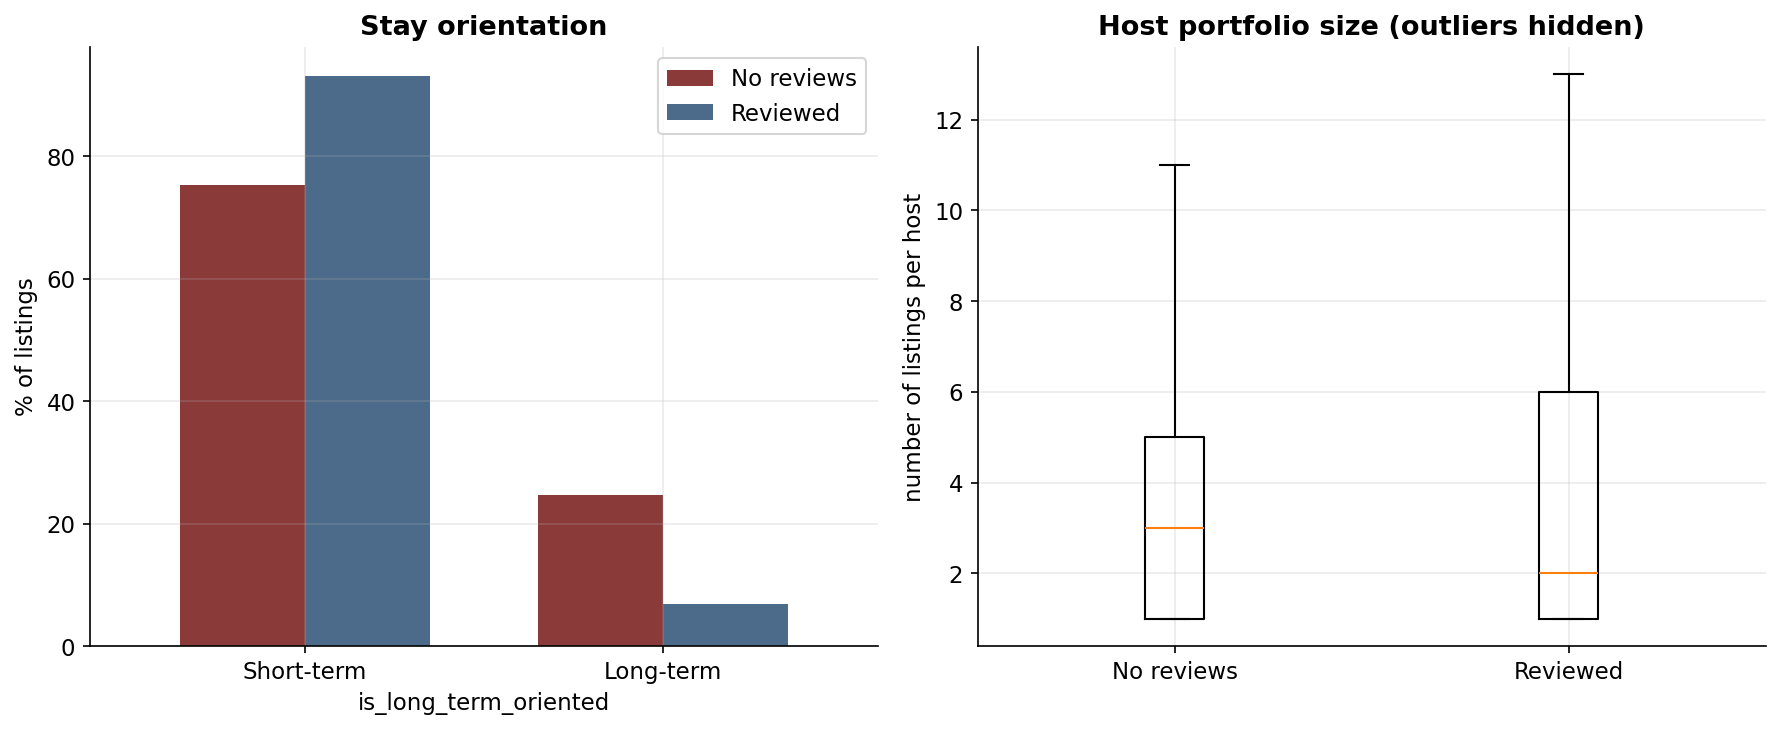

,No reviews,Reviewed
is_long_term_oriented,,
Short-term,75.3,93.2
Long-term,24.7,6.8


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lt_compare = pd.DataFrame({
    'No reviews': listings_no_review['is_long_term_oriented'].value_counts(normalize=True).mul(100),
    'Reviewed': listings_reviewed['is_long_term_oriented'].value_counts(normalize=True).mul(100),
}).rename(index={0: 'Short-term', 1: 'Long-term'})
lt_compare.plot(kind='bar', ax=axes[0], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.7)
axes[0].set_title('Stay orientation')
axes[0].set_ylabel('% of listings')
axes[0].tick_params(axis='x', rotation=0)

portfolio_data = [
    listings_no_review['calculated_host_listings_count_log'].apply(np.expm1),
    listings_reviewed['calculated_host_listings_count_log'].apply(np.expm1),
]
axes[1].boxplot(portfolio_data, labels=['No reviews', 'Reviewed'], showfliers=False)
axes[1].set_title('Host portfolio size (outliers hidden)')
axes[1].set_ylabel('number of listings per host')

plt.tight_layout()
plt.show()

display(lt_compare.round(1))

Long-term orientation is the sharpest structural signal found in this comparison: 24.7% of no-review listings are long-term oriented, versus just 6.8% of reviewed listings. This directly explains the "no-review" mechanism itself: `is_long_term_oriented` was built in feature engineering around a ~28-30 day minimum-stay threshold, and Airbnb's own review system requires a completed stay before a guest can leave one. A month-plus minimum stay structurally produces far fewer completed bookings per unit time than a 1-3 night listing, so slower review accumulation is a direct consequence of how the listing is offered.

Portfolio size, however, runs in the *opposite* direction from the boxplot's visual impression: no-review listings show a **higher** median (3 vs. 2), even though the reviewed population's box stretches to a higher upper quartile and whisker. Both facts are true simultaneously: no-review hosts are more uniformly mid-sized operators, while reviewed listings include both more single-unit hosts *and* more large operators.

### 2.6 No-Review Strata Summary

The 14.2% of listings with no reviews differ from the reviewed population across several dimensions at once: they're modestly higher-priced, sit slightly further from the center, skew toward B&B/hotel-type and private-room configurations, and are somewhat under-represented in I Centro Storico specifically. The clearest single driver is stay orientation, which only accounts for a minority of the no-review population.

These listings are set aside from the clustering that follows, since their defining trait is an absence rather than a comparable market position, and mixing that structural difference into the same distance calculation risks building a cluster around it instead of genuine segmentation.

## 3. Geography Resolution

The feature set carries two ways to encode a listing's location: `geo_sector` (8 balanced compass directions) and `neighbourhood_cleansed` (15 administrative municipi). This section runs the empirical comparison on the feature set: two backbone variants, differing only in geography, compared across a full k-sweep on both cost and Gower-based silhouette.

### 3.1 Setup the Two Backbone Variants

In [23]:
backbone_continuous_cols = [c for c in continuous_cols if c in TABULAR_STRUCTURAL_COLS]
backbone_categorical_cols = [c for c in categorical_cols if c in TABULAR_STRUCTURAL_COLS]
backbone_binary_cols = [c for c in binary_cols if c in TABULAR_STRUCTURAL_COLS]

print(f"backbone continuous: {len(backbone_continuous_cols)}")
print(f"backbone categorical: {len(backbone_categorical_cols)}")
print(f"backbone binary: {len(backbone_binary_cols)}")

# Variant A: neighbourhood_cleansed instead of geo_sector
backbone_categorical_cols_A = [c for c in backbone_categorical_cols if c != 'geo_sector'] + ['neighbourhood_cleansed']
# Variant B: geo_sector (the current default)
backbone_categorical_cols_B = backbone_categorical_cols

print(f"\nVariant A (neighbourhood_cleansed): {len(backbone_categorical_cols_A)} categorical cols")
print(f"Variant B (geo_sector): {len(backbone_categorical_cols_B)} categorical cols")

listings_reviewed['neighbourhood_cleansed'] = neighbourhood_cleansed.loc[listings_reviewed.index].str.lower()
print(f"\nneighbourhood_cleansed sample values: {sorted(listings_reviewed['neighbourhood_cleansed'].unique())[:3]}...")

backbone continuous: 14
backbone categorical: 7
backbone binary: 14

Variant A (neighbourhood_cleansed): 7 categorical cols
Variant B (geo_sector): 7 categorical cols

neighbourhood_cleansed sample values: ['i centro storico', 'ii parioli/nomentano', 'iii monte sacro']...


### 3.2 Build Both Matrices

In [25]:
def build_kproto_matrix(continuous_cols_list, categorical_cols_list, binary_cols_list, source_df):
    """Assembles a combined DataFrame + categorical index list for KPrototypes."""
    X_cat = source_df[categorical_cols_list + binary_cols_list].copy()
    for col in binary_cols_list:
        X_cat[col] = X_cat[col].astype(int).astype(str)

    X_cont = source_df[continuous_cols_list].copy()
    scaler_local = StandardScaler()
    X_cont_scaled = pd.DataFrame(
        scaler_local.fit_transform(X_cont),
        columns=continuous_cols_list,
        index=source_df.index
    )

    X_comb = pd.concat([X_cont_scaled, X_cat], axis=1)
    cat_idx = list(range(len(continuous_cols_list), X_comb.shape[1]))
    return X_comb, cat_idx

X_backbone_A, cat_idx_A = build_kproto_matrix(
    backbone_continuous_cols, backbone_categorical_cols_A, backbone_binary_cols, listings_reviewed
)
X_backbone_B, cat_idx_B = build_kproto_matrix(
    backbone_continuous_cols, backbone_categorical_cols_B, backbone_binary_cols, listings_reviewed
)

print(f"X_backbone_A (neighbourhood_cleansed): {X_backbone_A.shape}, categorical indices {cat_idx_A[0]}-{cat_idx_A[-1]}")
print(f"X_backbone_B (geo_sector): {X_backbone_B.shape}, categorical indices {cat_idx_B[0]}-{cat_idx_B[-1]}")

print(f"\nshapes match: {X_backbone_A.shape == X_backbone_B.shape}")

X_backbone_A (neighbourhood_cleansed): (30718, 35), categorical indices 14-34
X_backbone_B (geo_sector): (30718, 35), categorical indices 14-34

shapes match: True


### 3.3 K-Sweep for Both Variants 

In [26]:
from kmodes.kprototypes import KPrototypes
import time

K_RANGE = range(3, 11)
sweep_results = {'A': {}, 'B': {}}

for variant, (X_variant, cat_idx) in [('A', (X_backbone_A, cat_idx_A)), ('B', (X_backbone_B, cat_idx_B))]:
    print(f"\n=== Variant {variant} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_variant.to_numpy(), categorical=cat_idx)
        elapsed = time.time() - start

        sweep_results[variant][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== Variant A ===
  k=3: cost=410093.4, 28.9s
  k=4: cost=389424.1, 33.5s
  k=5: cost=371400.3, 46.6s
  k=6: cost=358044.3, 61.6s
  k=7: cost=348335.4, 37.2s
  k=8: cost=337622.6, 106.5s
  k=9: cost=331316.0, 54.1s
  k=10: cost=322981.4, 71.5s

=== Variant B ===
  k=3: cost=414523.3, 26.9s
  k=4: cost=393807.6, 32.4s
  k=5: cost=375623.8, 48.4s
  k=6: cost=362441.2, 110.9s
  k=7: cost=352459.9, 34.8s
  k=8: cost=344492.0, 49.5s
  k=9: cost=335402.8, 70.0s
  k=10: cost=327374.3, 61.4s


### 3.4 Stratified Sampling & Gower Silhouette

In [27]:
import gower
from sklearn.metrics import silhouette_score

SAMPLE_SIZE = 8000
MIN_PER_CLUSTER = 30

def stratified_sample_indices(labels, sample_size=SAMPLE_SIZE, min_per_cluster=MIN_PER_CLUSTER, random_state=42):
    """Proportional stratified sample by cluster label, with a floor per cluster
    so rare segments survive the sample even if their proportional share would round to ~0."""
    rng = np.random.RandomState(random_state)
    labels_series = pd.Series(labels)
    cluster_sizes = labels_series.value_counts()

    sampled_idx = []
    for cluster_id, size in cluster_sizes.items():
        proportional_n = int(round(sample_size * size / len(labels_series)))
        n_to_sample = max(min_per_cluster, proportional_n)
        n_to_sample = min(n_to_sample, size)
        cluster_idx = labels_series[labels_series == cluster_id].index.to_numpy()
        chosen = rng.choice(cluster_idx, size=n_to_sample, replace=False)
        sampled_idx.extend(chosen)

    return np.array(sampled_idx)


def compute_gower_silhouette(X_variant, cat_idx, labels, sample_idx):
    """Computes Gower distance + silhouette on a sample, with categorical columns
    passed explicitly — gower's auto-detection via np.issubdtype breaks on
    pandas 3.x's native StringDtype, so we bypass it entirely."""
    X_sample = X_variant.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_features_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_features_mask[cat_idx] = True

    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_features_mask)
    return silhouette_score(gower_dist, labels_sample, metric='precomputed'), len(sample_idx)


for variant, (X_variant, cat_idx) in [('A', (X_backbone_A, cat_idx_A)), ('B', (X_backbone_B, cat_idx_B))]:
    print(f"\n=== Variant {variant} ===")
    for k in K_RANGE:
        labels = sweep_results[variant][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_variant, cat_idx, labels, sample_idx)

        sweep_results[variant][k]['silhouette'] = sil_score
        sweep_results[variant][k]['sample_size'] = n_sampled
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== Variant A ===
  k=3: silhouette=0.0810 (sample n=8000)
  k=4: silhouette=0.0573 (sample n=8000)
  k=5: silhouette=0.0530 (sample n=8000)
  k=6: silhouette=0.0361 (sample n=8000)
  k=7: silhouette=0.0347 (sample n=8001)
  k=8: silhouette=0.0323 (sample n=8001)
  k=9: silhouette=0.0259 (sample n=8000)
  k=10: silhouette=0.0184 (sample n=8001)

=== Variant B ===
  k=3: silhouette=0.0801 (sample n=8000)
  k=4: silhouette=0.0515 (sample n=8000)
  k=5: silhouette=0.0499 (sample n=8000)
  k=6: silhouette=0.0361 (sample n=8000)
  k=7: silhouette=0.0351 (sample n=8001)
  k=8: silhouette=0.0253 (sample n=8000)
  k=9: silhouette=0.0249 (sample n=8000)
  k=10: silhouette=0.0221 (sample n=7998)


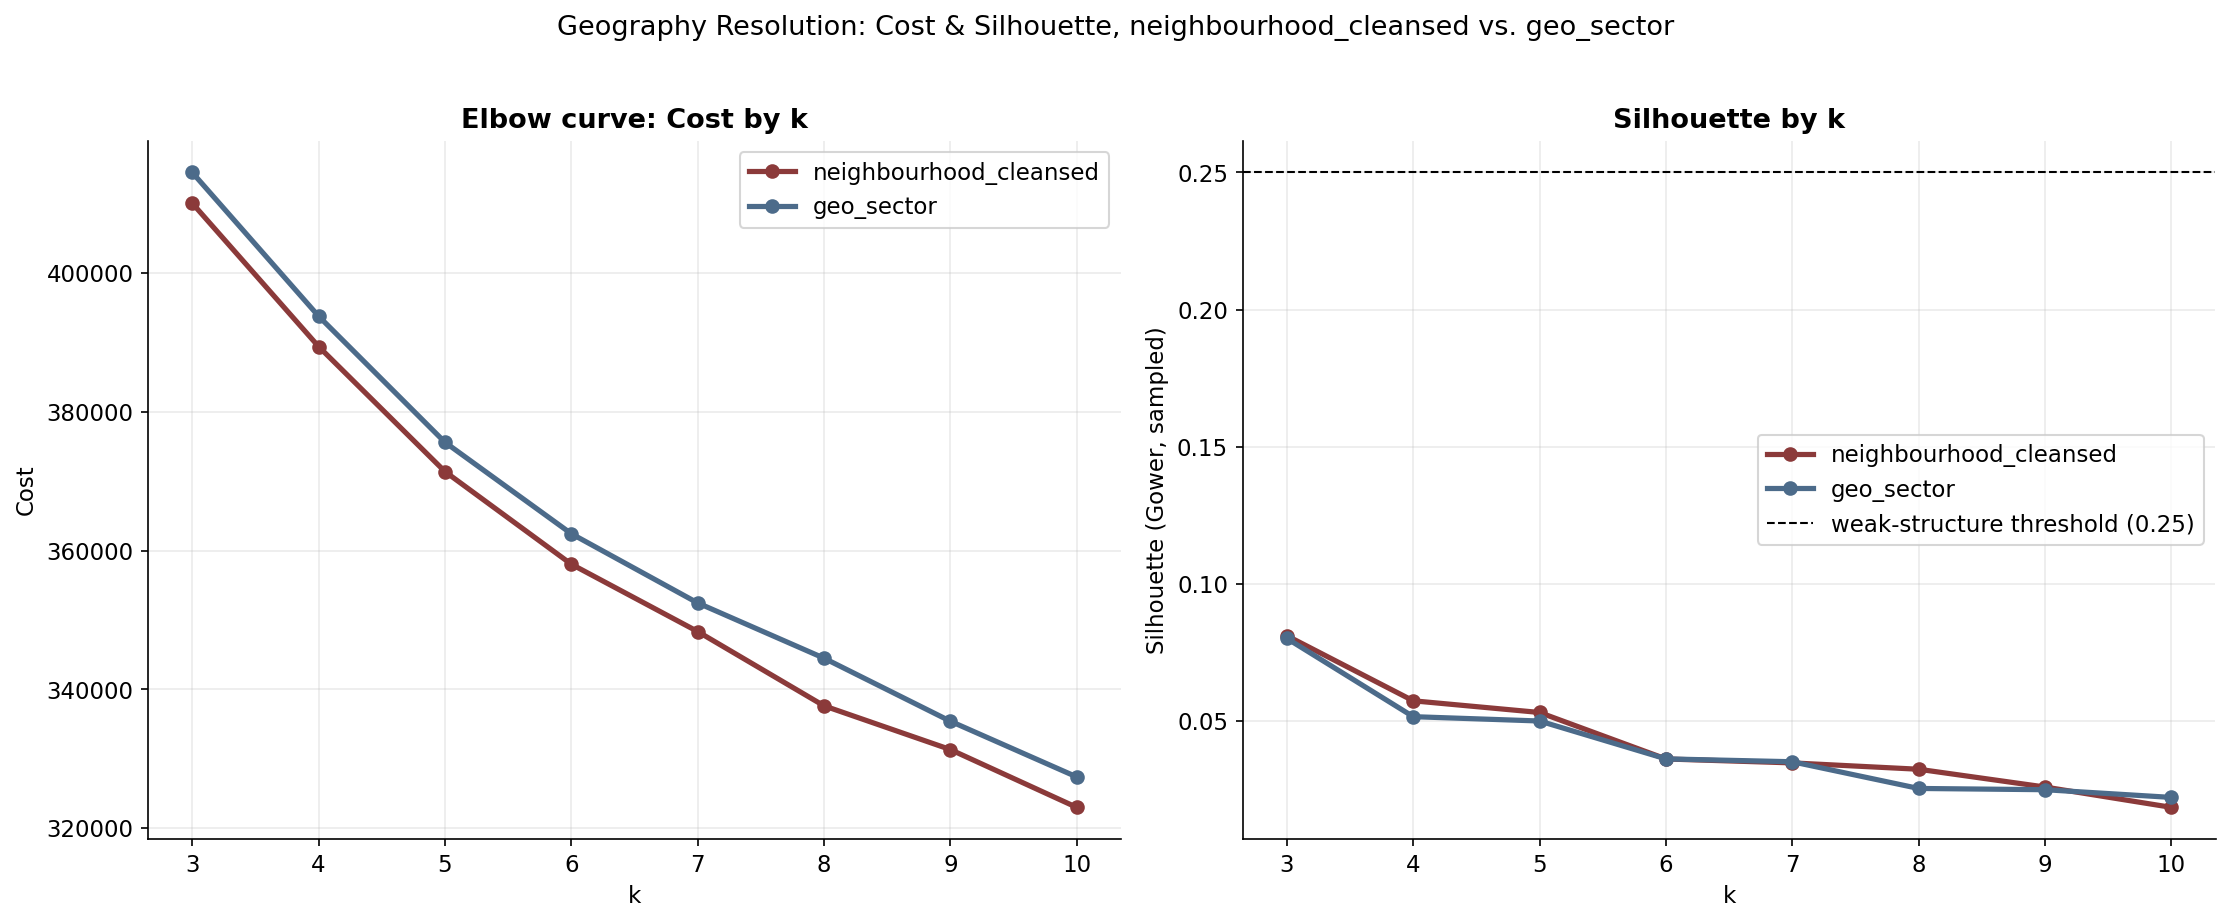

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for variant, color, label in [('A', ROME_PALETTE['primary'], 'neighbourhood_cleansed'),
                                ('B', ROME_PALETTE['secondary'], 'geo_sector')]:
    costs = [sweep_results[variant][k]['cost'] for k in K_RANGE]
    axes[0].plot(list(K_RANGE), costs, marker='o', color=color, linewidth=2.5, label=label)

axes[0].set_xlabel('k')
axes[0].set_ylabel('Cost')
axes[0].set_title('Elbow curve: Cost by k')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

for variant, color, label in [('A', ROME_PALETTE['primary'], 'neighbourhood_cleansed'),
                                ('B', ROME_PALETTE['secondary'], 'geo_sector')]:
    sils = [sweep_results[variant][k]['silhouette'] for k in K_RANGE]
    axes[1].plot(list(K_RANGE), sils, marker='o', color=color, linewidth=2.5, label=label)

axes[1].axhline(0.25, color='black', linestyle='--', linewidth=1, label='weak-structure threshold (0.25)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (Gower, sampled)')
axes[1].set_title('Silhouette by k')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.suptitle('Geography Resolution: Cost & Silhouette, neighbourhood_cleansed vs. geo_sector', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both geo variants produce nearly identical cost and silhouette curves at every k, a difference of 0.001-0.006 in silhouette, far smaller than the variation across k itself. Silhouette peaks at k=3 for both (≈0.08) and declines monotonically as k grows, staying well below the conventional 0.25 threshold for weak-but-real structure across the whole range, being a further sign of how little geography *encoding* affects cluster separation on its own, meaning that geography's strong in predicting price, not in driving cluster boundaries.

Since neither cost nor silhouette shows a measurable advantage, the deciding factor is practical: `geo_sector`'s 8 balanced categories avoid `neighbourhood_cleansed`'s severe imbalance (I Centro Storico alone holds around half the market). At equal measured quality, the more balanced encoding is preferred. **`geo_sector` is carried forward as the geography input.**

Gamma is left untuned here by design, as both variants ran at the same default value specifically so the comparison isolated the geography choice alone.

## 4. Baseline Tuning

Section 3 resolved the geography input but left gamma at its automatic default for both variants, but not a tuned choice. This section runs a full k×gamma grid on the now-fixed backbone (`geo_sector` + Structure + Host) to find the best-supported configuration before layering any NLP features on top.

### 4.1 Setup the Gamma Range

In [29]:
default_gamma = X_backbone_B[backbone_continuous_cols].std().mean()
print(f"kmodes default gamma (mean std of numeric columns): {default_gamma:.4f}")

GAMMA_RANGE = [default_gamma * m for m in [0.25, 0.5, 1.0, 2.0, 4.0]]
print(f"\ngamma grid: {[round(g, 4) for g in GAMMA_RANGE]}")

kmodes default gamma (mean std of numeric columns): 1.0000

gamma grid: [np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(4.0001)]


### 4.2 Full k×gamma Grid on Backbone

In [30]:
baseline_grid_results = {}

for gamma in GAMMA_RANGE:
    gamma_key = round(gamma, 4)
    baseline_grid_results[gamma_key] = {}
    print(f"\n=== gamma={gamma_key} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, gamma=gamma, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_backbone_B.to_numpy(), categorical=cat_idx_B)
        elapsed = time.time() - start

        baseline_grid_results[gamma_key][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== gamma=0.25 ===
  k=3: cost=376890.3, 29.1s
  k=4: cost=356610.0, 65.7s
  k=5: cost=338736.0, 62.0s
  k=6: cost=325570.3, 40.0s
  k=7: cost=315789.2, 44.0s
  k=8: cost=305144.3, 80.7s
  k=9: cost=298200.5, 89.9s
  k=10: cost=291434.7, 59.0s

=== gamma=0.5 ===
  k=3: cost=414524.5, 26.7s
  k=4: cost=393808.8, 33.8s
  k=5: cost=375625.0, 47.1s
  k=6: cost=362442.4, 108.4s
  k=7: cost=352461.1, 33.8s
  k=8: cost=344493.2, 48.6s
  k=9: cost=335403.9, 72.7s
  k=10: cost=327375.5, 60.2s

=== gamma=1.0 ===
  k=3: cost=487849.5, 33.9s
  k=4: cost=468803.6, 36.9s
  k=5: cost=449257.4, 43.0s
  k=6: cost=434929.4, 39.4s
  k=7: cost=426916.4, 52.1s
  k=8: cost=415363.1, 32.3s
  k=9: cost=404602.6, 51.1s
  k=10: cost=399036.0, 102.6s

=== gamma=2.0 ===
  k=3: cost=630925.3, 43.9s
  k=4: cost=606680.5, 48.0s
  k=5: cost=592554.1, 29.7s
  k=6: cost=572007.2, 33.8s
  k=7: cost=557872.3, 33.2s
  k=8: cost=547215.6, 51.8s
  k=9: cost=539727.0, 114.9s
  k=10: cost=530662.8, 63.2s

=== gamma=4.0001 ==

### 4.3 Stratified Sampling + Gower Silhouette

In [31]:
for gamma_key in baseline_grid_results:
    print(f"\n=== gamma={gamma_key} ===")
    for k in K_RANGE:
        labels = baseline_grid_results[gamma_key][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_backbone_B, cat_idx_B, labels, sample_idx)

        baseline_grid_results[gamma_key][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== gamma=0.25 ===
  k=3: silhouette=0.0815 (sample n=8000)
  k=4: silhouette=0.0501 (sample n=7999)
  k=5: silhouette=0.0474 (sample n=8000)
  k=6: silhouette=0.0345 (sample n=7999)
  k=7: silhouette=0.0306 (sample n=8000)
  k=8: silhouette=0.0244 (sample n=7999)
  k=9: silhouette=0.0266 (sample n=7999)
  k=10: silhouette=0.0162 (sample n=8000)

=== gamma=0.5 ===
  k=3: silhouette=0.0801 (sample n=8000)
  k=4: silhouette=0.0515 (sample n=8000)
  k=5: silhouette=0.0499 (sample n=8000)
  k=6: silhouette=0.0361 (sample n=8000)
  k=7: silhouette=0.0348 (sample n=8000)
  k=8: silhouette=0.0253 (sample n=8000)
  k=9: silhouette=0.0249 (sample n=8000)
  k=10: silhouette=0.0221 (sample n=7998)

=== gamma=1.0 ===
  k=3: silhouette=0.0770 (sample n=8000)
  k=4: silhouette=0.0591 (sample n=8000)
  k=5: silhouette=0.0609 (sample n=8000)
  k=6: silhouette=0.0428 (sample n=8000)
  k=7: silhouette=0.0335 (sample n=7999)
  k=8: silhouette=0.0372 (sample n=8000)
  k=9: silhouette=0.0377 (sample n=799

### 4.4 Visualization

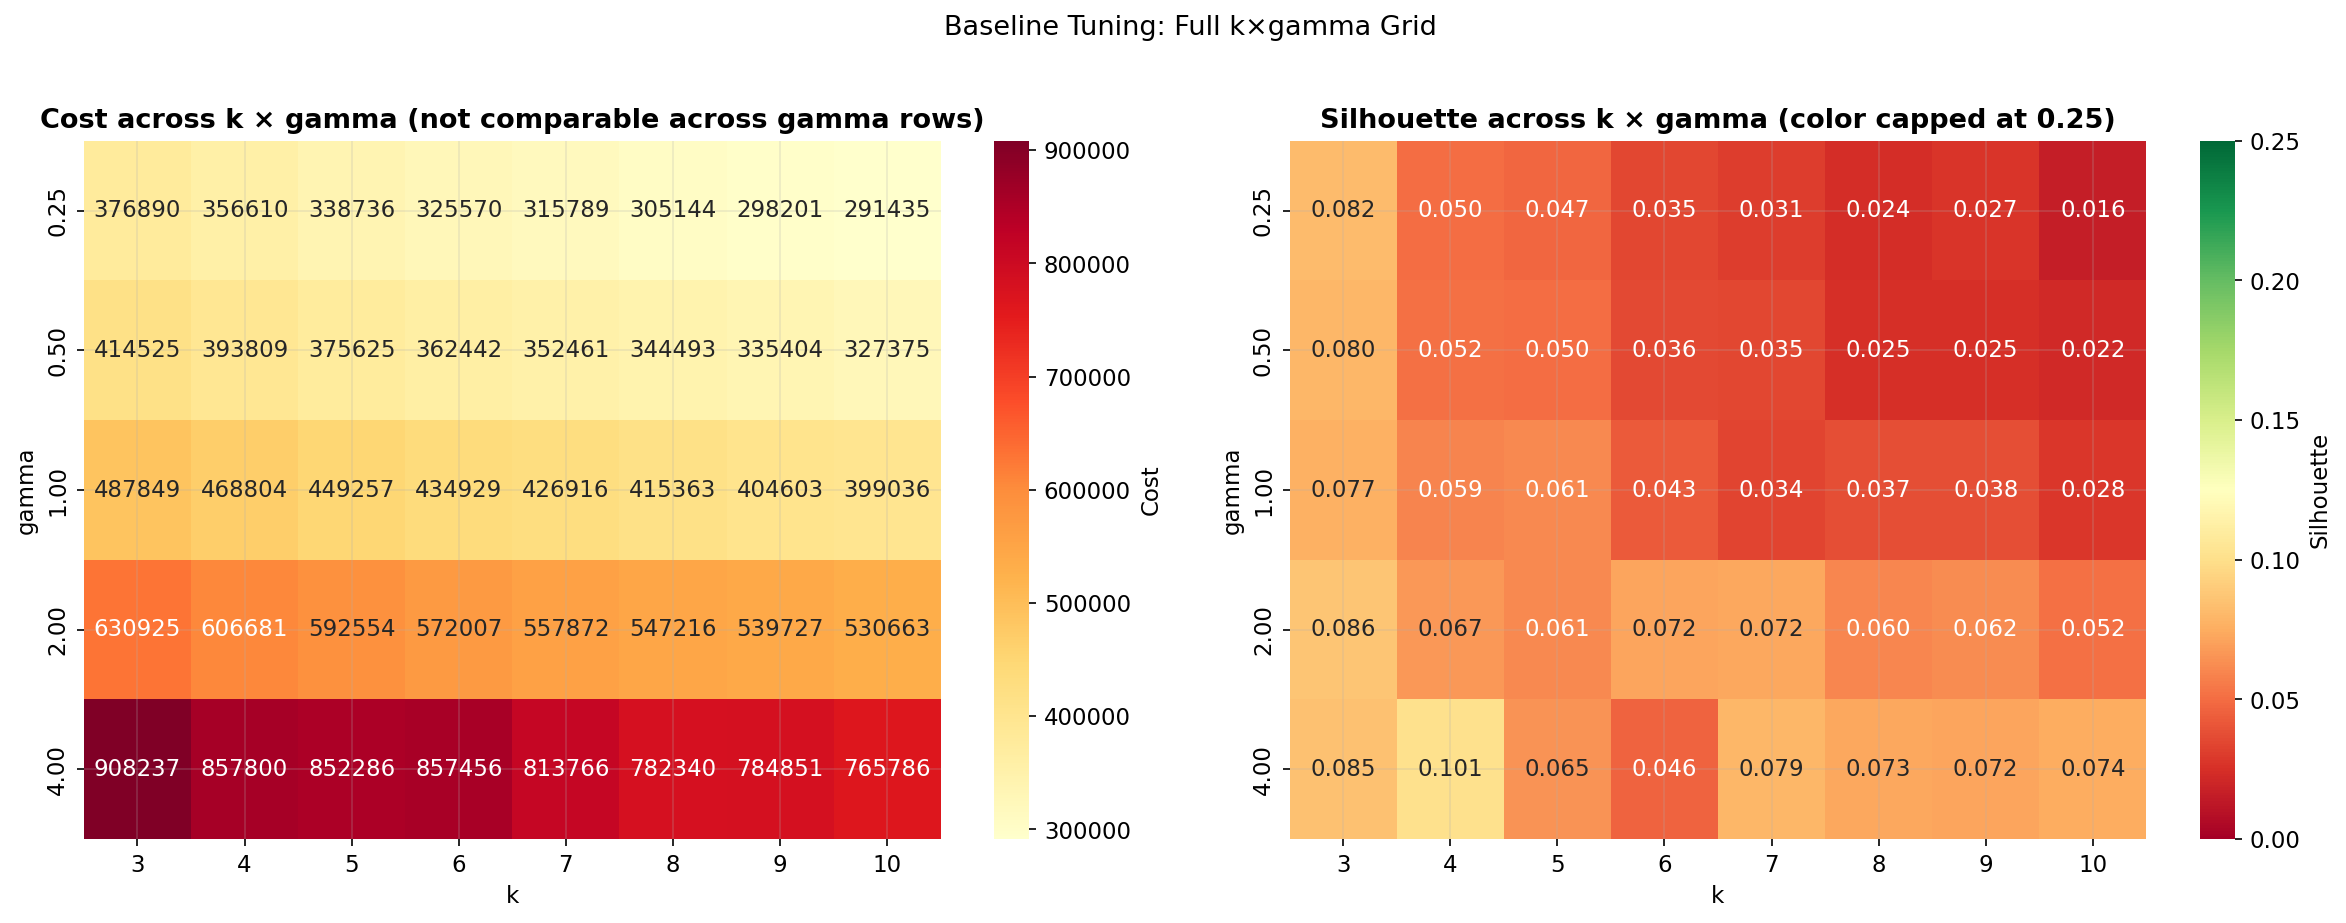

best combination: gamma=4.0001, k=4, silhouette=0.1007


In [32]:
gamma_labels = [f'{g:.2f}' for g in baseline_grid_results.keys()]
k_labels = list(K_RANGE)

cost_matrix = np.array([[baseline_grid_results[g][k]['cost'] for k in K_RANGE] for g in baseline_grid_results])
sil_matrix = np.array([[baseline_grid_results[g][k]['silhouette'] for k in K_RANGE] for g in baseline_grid_results])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cost_matrix, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=k_labels, yticklabels=gamma_labels,
            ax=axes[0], cbar_kws={'label': 'Cost'})
axes[0].set_xlabel('k')
axes[0].set_ylabel('gamma')
axes[0].set_title('Cost across k × gamma (not comparable across gamma rows)')

sns.heatmap(sil_matrix, annot=True, fmt='.3f', cmap='RdYlGn', xticklabels=k_labels, yticklabels=gamma_labels,
            ax=axes[1], vmin=0, vmax=0.25, cbar_kws={'label': 'Silhouette'})
axes[1].set_xlabel('k')
axes[1].set_ylabel('gamma')
axes[1].set_title('Silhouette across k × gamma (color capped at 0.25)')

plt.suptitle('Baseline Tuning: Full k×gamma Grid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_gamma_key = max(baseline_grid_results, key=lambda g: max(baseline_grid_results[g][k]['silhouette'] for k in K_RANGE))
best_k = max(K_RANGE, key=lambda k: baseline_grid_results[best_gamma_key][k]['silhouette'])
best_sil = baseline_grid_results[best_gamma_key][best_k]['silhouette']
print(f"best combination: gamma={best_gamma_key}, k={best_k}, silhouette={best_sil:.4f}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Librar

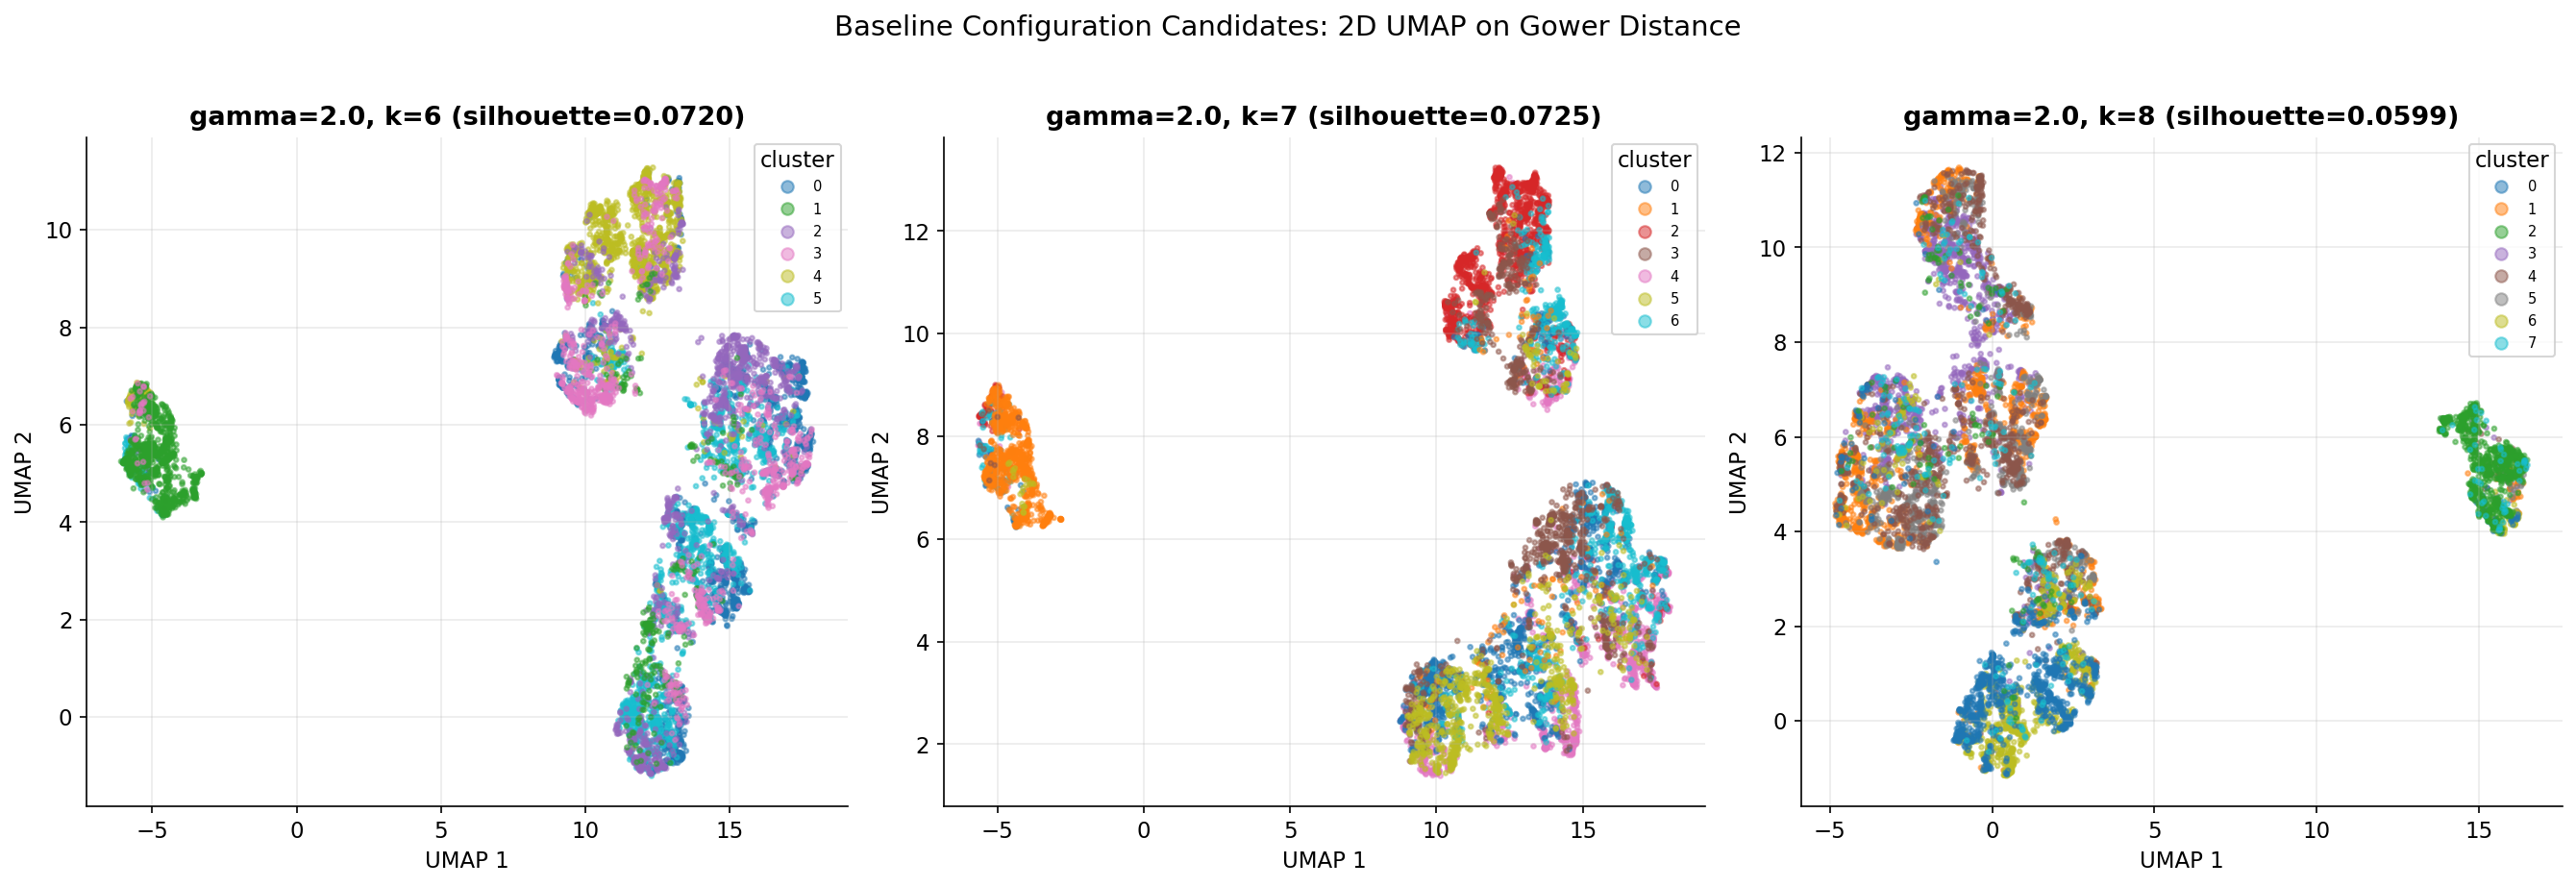

In [33]:
import umap

def visualize_cluster_labels(X_variant, cat_idx, labels, title, sample_size=8000):
    sample_idx = stratified_sample_indices(labels, sample_size=sample_size)
    X_sample = X_variant.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_mask[cat_idx] = True
    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_mask)

    reducer = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
    embedding = reducer.fit_transform(gower_dist)
    return embedding, labels_sample

CANDIDATES_TO_VISUALIZE = [(2.0, 6), (2.0, 7), (2.0, 8)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (gamma, k) in zip(axes, CANDIDATES_TO_VISUALIZE):
    labels = baseline_grid_results[gamma][k]['labels']
    embedding, labels_sample = visualize_cluster_labels(X_backbone_B, cat_idx_B, labels, f'gamma={gamma}, k={k}')

    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels_sample, cmap='tab10', s=5, alpha=0.5)
    sil = baseline_grid_results[gamma][k]['silhouette']
    ax.set_title(f'gamma={gamma}, k={k} (silhouette={sil:.4f})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(*scatter.legend_elements(), title='cluster', loc='upper right', fontsize=7)

plt.suptitle('Baseline Configuration Candidates: 2D UMAP on Gower Distance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

UMAP confirms what the silhouette heatmap already suggested. At k=6/7/8, one small, well-isolated island appears consistently on the left. At k=7 this is cluster 1, almost cleanly separated from everything else. The rest of the sample forms one large, poorly-separated main cloud split into two loose sub-blobs (upper-right, lower-right), inside which individual cluster colors are almost fully intermixed.

`gamma=2.0`, `k=7` is confirmed as the baseline configuration. It isolates the one small cluster, without fragmenting the main cloud into more pieces than the data supports.

**Baseline Configuration, fixed going forward**: features = `geo_sector` + Structure + Host (35 columns), `k=7`, `gamma=2.0`.

## 5. NLP Feature Experiments

This section asks the main question: does text change that picture? Two NLP feature groups are layered onto the fixed baseline separately - embeddings/persona and tone/topic stylometry plus the full combination, each run through the same k-sweep at the baseline's tuned `gamma=2.0`.

### 5.1 Setup the NLP Feature Groups

In [39]:
EMBEDDING_PERSONA_COLS = {c for c in NLP_COLS if c.startswith('embedding_pc') or c in {'text_persona', 'n_embedded_reviews'}}

CONTENT_FLAG_COLS = {c for c in NLP_COLS if c in binary_cols and c.startswith('has_') and c != 'has_no_neutral_sentiment'}

NLP_CORE_COLS = NLP_COLS - EMBEDDING_PERSONA_COLS - CONTENT_FLAG_COLS

print(f"NLP core (tone/topic/sentiment, no flags, no embeddings): {len(NLP_CORE_COLS)} columns")
print(f"Content flags (has_X binary): {len(CONTENT_FLAG_COLS)} columns")
for col in sorted(CONTENT_FLAG_COLS):
    print(f"  {col}")
print(f"Embeddings/persona: {len(EMBEDDING_PERSONA_COLS)} columns")

all_three = NLP_CORE_COLS | CONTENT_FLAG_COLS | EMBEDDING_PERSONA_COLS
assert all_three == NLP_COLS, f"mismatch: {NLP_COLS - all_three} missing, {all_three - NLP_COLS} extra"
assert len(NLP_CORE_COLS) + len(CONTENT_FLAG_COLS) + len(EMBEDDING_PERSONA_COLS) == len(NLP_COLS)
print(f"\nthree groups reconstruct NLP_COLS exactly ({len(NLP_COLS)} total)")

NLP core (tone/topic/sentiment, no flags, no embeddings): 83 columns
Content flags (has_X binary): 11 columns
  has_description_self_ref
  has_host_about_atmosphere_lively
  has_host_about_atmosphere_quiet
  has_host_about_budget
  has_host_about_luxury
  has_host_about_professionalism
  has_neighborhood_overview_budget
  has_neighborhood_overview_exclaim
  has_neighborhood_overview_family
  has_neighborhood_overview_romantic
  has_neighborhood_overview_self_ref
Embeddings/persona: 12 columns

three groups reconstruct NLP_COLS exactly (106 total)


### 5.2 Build the Experiment Matrices

In [40]:
def build_experiment_matrix(extra_cols_set, source_df):
    """Backbone (geo_sector) + a given NLP column set, split by dtype and
    assembled the same way as build_kproto_matrix throughout this notebook."""
    extra_cont = [c for c in extra_cols_set if c in continuous_cols]
    extra_cat = [c for c in extra_cols_set if c in categorical_cols]
    extra_bin = [c for c in extra_cols_set if c in binary_cols]

    continuous_list = backbone_continuous_cols + extra_cont
    categorical_list = backbone_categorical_cols_B + extra_cat  
    binary_list = backbone_binary_cols + extra_bin

    return build_kproto_matrix(continuous_list, categorical_list, binary_list, source_df)

EXPERIMENTS_NLP_COLS = {
    'Exp1_nlp_core': NLP_CORE_COLS,
    'Exp2_core_flags': NLP_CORE_COLS | CONTENT_FLAG_COLS,
    'Exp3_core_embed': NLP_CORE_COLS | EMBEDDING_PERSONA_COLS,
    'Exp4_full': NLP_CORE_COLS | CONTENT_FLAG_COLS | EMBEDDING_PERSONA_COLS,
}

experiment_matrices = {}
for exp_name, col_set in EXPERIMENTS_NLP_COLS.items():
    X_exp, cat_idx_exp = build_experiment_matrix(col_set, listings_reviewed)
    experiment_matrices[exp_name] = (X_exp, cat_idx_exp)
    print(f"{exp_name}: {X_exp.shape} ({len(col_set)} NLP columns added to backbone)")

print(f"\nBaseline (§4) shape for reference: {X_backbone_B.shape}")

Exp1_nlp_core: (30718, 118) (83 NLP columns added to backbone)
Exp2_core_flags: (30718, 129) (94 NLP columns added to backbone)
Exp3_core_embed: (30718, 130) (95 NLP columns added to backbone)
Exp4_full: (30718, 141) (106 NLP columns added to backbone)

Baseline (§4) shape for reference: (30718, 35)


### 5.3 K-Sweep for Each Experiment

In [41]:
FIXED_GAMMA = 2.0
nlp_sweep_results = {}

for exp_name, (X_exp, cat_idx) in experiment_matrices.items():
    nlp_sweep_results[exp_name] = {}
    print(f"\n=== {exp_name} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, gamma=FIXED_GAMMA, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_exp.to_numpy(), categorical=cat_idx)
        elapsed = time.time() - start

        nlp_sweep_results[exp_name][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== Exp1_nlp_core ===
  k=3: cost=3030097.7, 31.8s
  k=4: cost=2996749.0, 39.2s
  k=5: cost=2918513.7, 55.0s
  k=6: cost=2919203.2, 43.3s
  k=7: cost=2886942.9, 48.9s
  k=8: cost=2825670.2, 69.3s
  k=9: cost=2811186.3, 56.3s
  k=10: cost=2835754.8, 87.9s

=== Exp2_core_flags ===
  k=3: cost=3053768.6, 35.5s
  k=4: cost=2997456.2, 37.7s
  k=5: cost=2956735.3, 48.5s
  k=6: cost=2929251.8, 40.7s
  k=7: cost=2865577.7, 57.6s
  k=8: cost=2843288.4, 51.9s
  k=9: cost=2820870.3, 101.3s
  k=10: cost=2812879.8, 73.7s

=== Exp3_core_embed ===
  k=3: cost=3366494.1, 34.7s
  k=4: cost=3309102.2, 46.0s
  k=5: cost=3230997.5, 46.4s
  k=6: cost=3198778.0, 53.7s
  k=7: cost=3168756.6, 54.3s
  k=8: cost=3158898.0, 69.6s
  k=9: cost=3127818.9, 55.0s
  k=10: cost=3110074.4, 126.6s

=== Exp4_full ===
  k=3: cost=3386622.1, 39.8s
  k=4: cost=3333381.2, 43.1s
  k=5: cost=3254943.9, 78.0s
  k=6: cost=3217811.1, 53.7s
  k=7: cost=3192270.9, 60.5s
  k=8: cost=3165483.9, 70.3s
  k=9: cost=3148576.8, 106.8s
  k

### 5.4 Stratified Sampling + Gower Silhouette

In [44]:
import gc

for exp_name, (X_exp, cat_idx) in experiment_matrices.items():
    print(f"\n=== {exp_name} ===")
    for k in K_RANGE:
        if 'silhouette' in nlp_sweep_results[exp_name][k]:
            print(f"  k={k}: already computed ({nlp_sweep_results[exp_name][k]['silhouette']:.4f}), skipping")
            continue

        start = time.time()
        labels = nlp_sweep_results[exp_name][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_exp, cat_idx, labels, sample_idx)
        elapsed = time.time() - start

        nlp_sweep_results[exp_name][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled}, {elapsed:.1f}s)")

        del sample_idx
        gc.collect()


=== Exp1_nlp_core ===
  k=3: already computed (0.0777), skipping
  k=4: already computed (0.0695), skipping
  k=5: already computed (0.0555), skipping
  k=6: already computed (0.0398), skipping
  k=7: already computed (0.0324), skipping
  k=8: already computed (0.0578), skipping
  k=9: already computed (0.0486), skipping
  k=10: already computed (0.0280), skipping

=== Exp2_core_flags ===
  k=3: already computed (0.0700), skipping
  k=4: already computed (0.0729), skipping
  k=5: already computed (0.0422), skipping
  k=6: already computed (0.0342), skipping
  k=7: already computed (0.0559), skipping
  k=8: already computed (0.0549), skipping
  k=9: already computed (0.0471), skipping
  k=10: already computed (0.0359), skipping

=== Exp3_core_embed ===
  k=3: already computed (0.0524), skipping
  k=4: already computed (0.0496), skipping
  k=5: already computed (0.0711), skipping
  k=6: already computed (0.0621), skipping
  k=7: already computed (0.0633), skipping
  k=8: already compute

Across all four experiments, silhouette peaks early (k=3-5) and declines from there, mirroring the shape already seen in the baseline tuning. None of the four configurations produces a clear, convincing improvement: the NLP core alone reaches the highest single value in the table (0.0777 at k=3), adding content flags on top leaves the picture essentially unchanged (0.0729 at k=4), and adding embeddings (whether alone or combined with flags) pulls the best achievable silhouette down rather than up (0.0711 and 0.0648 respectively). No configuration approaches the 0.25 threshold for real, well-separated structure anywhere in this grid.

Read together, this doesn't point to text carrying an obviously strong, separable signal on top of the tabular backbone. If anything, richer NLP combinations (embeddings, and especially the full set) coincide with a *lower* best-case silhouette than the leaner core-only version.

### 5.5 ARI Comparison Against Baseline

In [ ]:
from sklearn.metrics import adjusted_rand_score

CROSSTAB_CANDIDATES = [('Exp1_nlp_core', 3), ('Exp2_core_flags', 4), ('Exp3_core_embed', 5), ('Exp4_full', 5)]

baseline_labels_k7 = baseline_grid_results[2.0][7]['labels']

ari_results_v2 = []
for exp_name, k in CROSSTAB_CANDIDATES:
    exp_labels = nlp_sweep_results[exp_name][k]['labels']
    ari = adjusted_rand_score(baseline_labels_k7, exp_labels)
    ari_results_v2.append({'experiment': exp_name, 'k': k, 'ARI_vs_baseline_k7': round(ari, 4)})
    print(f"{exp_name}, k={k}: ARI vs Baseline(k=7) = {ari:.4f}")

ari_df_v2 = pd.DataFrame(ari_results_v2)
display(ari_df_v2)

Exp1_nlp_core, k=3: ARI vs Baseline(k=7) = 0.0688
Exp2_core_flags, k=4: ARI vs Baseline(k=7) = 0.0772
Exp3_core_embed, k=5: ARI vs Baseline(k=7) = 0.0851
Exp4_full, k=5: ARI vs Baseline(k=7) = 0.0779


,experiment,k,ARI_vs_baseline_k7
0,Exp1_nlp_core,3,0.0688
1,Exp2_core_flags,4,0.0772
2,Exp3_core_embed,5,0.0851
3,Exp4_full,5,0.0779


In [47]:
for exp_name, k in CROSSTAB_CANDIDATES:
    exp_labels = nlp_sweep_results[exp_name][k]['labels']

    crosstab = pd.crosstab(
        pd.Series(baseline_labels_k7, name='Baseline cluster (k=7)'),
        pd.Series(exp_labels, name=f'{exp_name} cluster (k={k})')
    )

    ari_value = ari_df_v2[(ari_df_v2.experiment == exp_name) & (ari_df_v2.k == k)]['ARI_vs_baseline_k7'].values[0]
    print(f"\n=== Baseline (k=7) vs. {exp_name} (k={k}), ARI={ari_value:.4f} ===")
    display(crosstab)


=== Baseline (k=7) vs. Exp1_nlp_core (k=3), ARI=0.0688 ===


Exp1_nlp_core cluster (k=3),0,1,2
Baseline cluster (k=7),,,
0,3904,926,195
1,2007,1202,504
2,1718,1660,1889
3,1270,663,1569
4,1041,1787,3366
5,942,802,1247
6,2882,785,359



=== Baseline (k=7) vs. Exp2_core_flags (k=4), ARI=0.0772 ===


Exp2_core_flags cluster (k=4),0,1,2,3
Baseline cluster (k=7),,,,
0,565,96,898,3466
1,455,439,1188,1631
2,696,1477,1581,1513
3,1581,877,479,565
4,1012,2808,1558,816
5,750,1045,672,524
6,507,228,805,2486



=== Baseline (k=7) vs. Exp3_core_embed (k=5), ARI=0.0851 ===


Exp3_core_embed cluster (k=5),0,1,2,3,4
Baseline cluster (k=7),,,,,
0,1267,704,106,2383,565
1,574,799,449,1107,784
2,1725,188,1474,279,1601
3,444,367,1105,1295,291
4,1240,13,2989,422,1530
5,385,215,1050,820,521
6,2019,660,175,406,766



=== Baseline (k=7) vs. Exp4_full (k=5), ARI=0.0779 ===


Exp4_full cluster (k=5),0,1,2,3,4
Baseline cluster (k=7),,,,,
0,1277,835,47,2156,710
1,613,1108,314,875,803
2,1821,1426,1543,286,191
3,372,726,760,1276,368
4,1322,1597,2882,380,13
5,429,812,819,715,216
6,2095,737,138,387,669


Every crosstab shows the same qualitative pattern: no baseline cluster survives with its mass concentrated in a single NLP-experiment column. Row mass instead spreads across most or all of the available columns, typically with the largest single cell holding only 20-45% of the row. It is a pattern closer to what two largely *independent* partitions would produce than to one being a refinement of the other. This is consistent with the low ARI values across all four experiments (0.07-0.09): the low scores aren't primarily an artifact of comparing different numbers of clusters, they reflect two genuinely different, weakly-related ways of grouping the same listings.

The one partial exception is Baseline cluster 4 against Exp3/Exp4's cluster 1, which both come in at just 13 listings. Beyond this single cell, no NLP configuration tested here produces a partition that reads as a clear refinement, split, or merge of the baseline structure. Adding text features changes the clustering, but into a comparably weak, differently-organized structure rather than a sharper or more clearly related one.

### 5.6 Summary

Adding text features to the tabular backbone doesn't produce a configuration that clusters more cleanly than the backbone alone. All four experiments show the same silhouette shape, and none crosses even a modest quality threshold. The NLP core alone reaches the best result in the whole grid (0.0777 at k=3). Content flags leave that essentially unchanged. Embeddings, alone or combined with the flags, actually pull the achievable ceiling down rather than up.

ARI and the crosstabs tell a consistent, complementary story: every NLP configuration produces a partition only weakly related to the backbone's own structure (ARI 0.07-0.09), and the crosstabs confirm this. Row mass spreads thinly across most columns in every table, with no baseline cluster surviving intact into any NLP-enriched configuration. Text changes the clustering, but into a differently-organized, comparably weak structure, not a sharper or clearly-related refinement of it.

Taken together, this doesn't rule out text carrying useful signal, but it does mean no single configuration tested here stands out as an obvious winner on the metrics used so far. Three candidates are carried forward for closer tuning:

- **`Exp1_nlp_core`, k=3** — the single best silhouette across the whole grid, and the simplest configuration (no flags, no embeddings) if it holds up under more careful tuning.
- **`Exp2_core_flags`, k=4** — nearly matches Exp1 while adding the content flags, worth checking whether that near-tie survives a proper gamma sweep or is just noise from a single random initialization.
- **`Exp3_core_embed`, k=5** — the only configuration where embeddings show a distinct local peak rather than a flat decline, worth checking whether that peak is reproducible or an artifact of `n_init=1`.